In [1]:
using Pkg
Pkg.activate("../")
Pkg.instantiate()

  Activating project at `~/Documents/PauliPropagation/mean_field/PauliOperators.jl`


In [2]:
using PauliOperators
using Plots
using LinearAlgebra
using Plots.PlotMeasures
# using KrylovKit


In [197]:
function heisenberg_xxx(N::Int; J::Real=1.0)
    H = PauliSum(N, ComplexF64)
    for i in 1:(N-1)
        H[PauliBasis(Pauli(N; X=[i, i+1]))] = 1J + 0im
        H[PauliBasis(Pauli(N; Y=[i, i+1]))] = 1J + 0im
        H[PauliBasis(Pauli(N; Z=[i, i+1]))] = 2J + 0im
    end
    return H
end

function ghz_hamiltonian(N::Int; J::Real=1.0, g::Real=0.1)
    H = PauliSum(N, ComplexF64)

    for i in 1:(N-1)
        H[PauliBasis(Pauli(N; Z=[i, i+1]))] = -J + 0im
    end

    H[PauliBasis(Pauli(N; X=collect(1:N)))] = -g + 0im

    return H
end
# Example usage:
# H = heisenberg_xxx(6; J=1.0)

ghz_hamiltonian (generic function with 1 method)

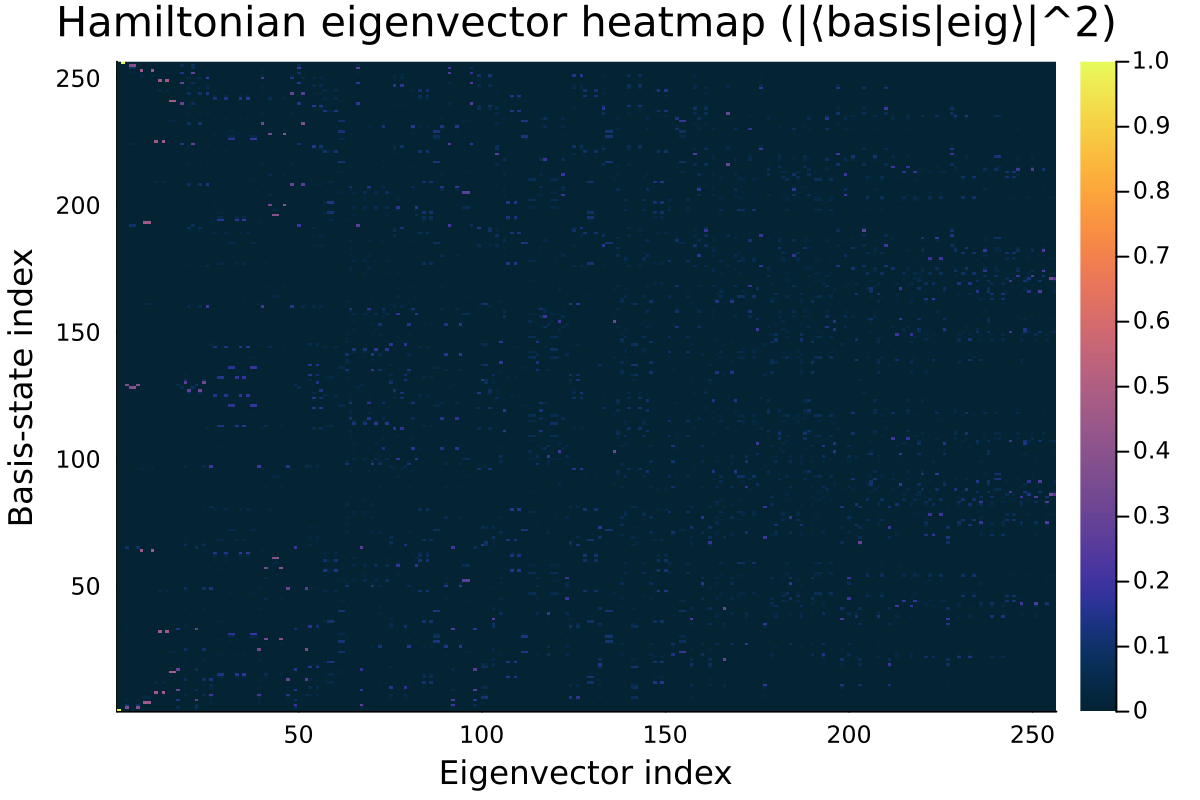

Eigenvalues: [-14.0, -14.0, -11.016962, -11.016962, -10.981727]
Eigenvectors with one dominant basis component: [1, 2]
Eigenvector 1  (λ = -14.0)
  |0⟩ : amplitude=1.0 + 0.0im, weight=1.0

Eigenvector 2  (λ = -14.0)
  |255⟩ : amplitude=1.0 + 0.0im, weight=1.0



In [209]:
N = 8
J = -1.0
g = 0.1
H = heisenberg_xxx(N, J=J)
# H = ghz_hamiltonian(N, J=J, g=g)
Hm = Hermitian(Matrix(H))
vals, vecs = eigen(Hm)
heat = abs.(vecs) .^ 2
println("Eigenvalues: $(round.(vals[1:5]; digits=6))")
p = heatmap(
    1:size(heat, 2),
    1:size(heat, 1),
    heat;
    xlabel="Eigenvector index",
    ylabel="Basis-state index",
    title="Hamiltonian eigenvector heatmap (|⟨basis|eig⟩|^2)",
    color=:thermal,
    clims=(0, 1),
    dpi=200,
)

# Keep only the single dominant computational-basis component of each eigenvector
keep = Int[]
for i in 1:size(vecs, 2)
    probs = abs.(vecs[:, i]) .^ 2
    if maximum(probs) > 0.99
        push!(keep, i)
    end
end

println("Eigenvectors with one dominant basis component: $(keep)")
for i in keep
    probs = abs.(vecs[:, i]) .^ 2
    j = argmax(probs)
    println("Eigenvector $i  (λ = $(round(vals[i]; digits=6)))")
    println("  |$(j-1)⟩ : amplitude=$(round(vecs[j, i]; digits=4)), weight=$(round(probs[j]; digits=4))")
    println()
end

display(p)
# vals

In [199]:
function ket_vector(ψ::Ket{N}) where {N}
    ψv = zeros(ComplexF64, Int(2^N))
    ψv[Int(ψ.v) + 1] = 1.0
    return ψv
end

function ground_reference_kets(H::PauliSum{N}; atol=1e-10, dominance=0.99) where {N}
    Hm = Hermitian(Matrix(H))
    vals, vecs = eigen(Hm)
    E0 = minimum(vals)
    ground_cols = findall(λ -> isapprox(λ, E0; atol=atol, rtol=0), vals)

    ground_weights = vec(sum(abs.(vecs[:, ground_cols]) .^ 2; dims=2))
    refs = Ket{N}.(Int128.(findall(w -> w >= dominance, ground_weights) .- 1))

    return E0, refs, ground_weights
end

function dominant_ground_reference(H::PauliSum{N}; atol=1e-10, dominance=0.99) where {N}
    E0, refs, ground_weights = ground_reference_kets(H; atol=atol, dominance=dominance)
    if isempty(refs)
        idx = argmax(ground_weights)
        error("No computational-basis state has ground-subspace weight >= $dominance. Best candidate is |$(idx - 1)> with weight $(round(ground_weights[idx]; digits=6)).")
    end
    return E0, refs[1], refs, ground_weights
end

function exact_two_point_curve(H::PauliSum{N}, Z_i::PauliSum{N}, Z_j::PauliSum{N}, ψ::Ket{N},
                               times::AbstractVector) where {N}
    Hm = Hermitian(Matrix(H))
    Zi = Matrix(Z_i)
    Zj = Matrix(Z_j)

    ψv = ket_vector(ψ)
    ϕv = Zj * ψv

    F = eigen(Hm)
    λ, V = F.values, F.vectors

    c_ψ = V' * ψv
    c_ϕ = V' * ϕv

    ev = zeros(ComplexF64, length(times))
    for (k, t) in enumerate(times)
        ψt = V * (cis.(-t .* λ) .* c_ψ)
        ϕt = V * (cis.(-t .* λ) .* c_ϕ)
        ev[k] = ψt' * Zi * ϕt
    end

    return ev
end

function get_weight_distribution(ps::PauliSum, N::Int)
    dist = zeros(Float64, N + 1)
    for (p, c) in ps
        w = weight(p)
        dist[w + 1] += abs2(c)
    end
    return dist
end


function trotter_ev_curve(H::PauliSum{N,T}, Oi::PauliSum{N,T}, Oj::PauliSum{N,T}, ψ::Ket{N},
                          times::AbstractVector, dt::Real,
                          truncation::TruncationStrategy, correction::CorrectionAccumulator=NoCorrection()) where {N,T}
    generators, angles = trotterize(H, dt; n_trotter=1, order=2)
    Ot = deepcopy(Oi)
    W_mat   = zeros(Float64, length(times), N + 1)
    ev      = zeros(ComplexF32, length(times))
    n_terms = zeros(Int,     length(times))
    ev[1]      = (expectation_value(Ot, ψ))
    n_terms[1] = length(Ot)
    W_mat[1, :] = get_weight_distribution(Ot, N)
    l2 = norm(H)
    for step in 2:length(times)
        Ot = evolve(Ot, generators, angles; truncation=truncation, correction=correction)
        # mul!(Ot, l2 / norm(Ot))
        # @show norm(Ot)
        Oij = Ot * Oj
        if correction isa EnergyCorrection
            ev[step] = (expectation_value(Oij, ψ) - correction.accumulated_energy)
        else
            ev[step]  = (expectation_value(Oij, ψ))
        end
        n_terms[step] = length(Oij)
        W_mat[step, :] = get_weight_distribution(Ot, N)
    end
    return ev, n_terms, W_mat
end

trotter_ev_curve (generic function with 2 methods)

In [210]:
N = 8
J = -1.0
H = heisenberg_xxx(N, J=J)

E0, ground_refs, ground_weights = ground_reference_kets(H)
order0 = partialsortperm(ground_weights, 1:min(8, length(ground_weights)), rev=true)

println("Ground-state energy E0 = $(round(E0; digits=8))")
println("Computational-basis states in the ground subspace (top 8 projector weights):")
for idx in order0
    println("  |$(idx-1)> : ground-subspace weight=$(round(ground_weights[idx]; digits=6))")
end

println("Single-reference ground states: ", [Int(ref.v) for ref in ground_refs])

# This block is intentionally separate from the heatmap block above.

Ground-state energy E0 = -14.0
Computational-basis states in the ground subspace (top 8 projector weights):
  |0> : ground-subspace weight=1.0
  |255> : ground-subspace weight=1.0
  |1> : ground-subspace weight=0.0
  |2> : ground-subspace weight=0.0
  |3> : ground-subspace weight=0.0
  |4> : ground-subspace weight=0.0
  |5> : ground-subspace weight=0.0
  |6> : ground-subspace weight=0.0
Single-reference ground states: [0, 255]


Ground-state energy E0 = -14.0
Using single computational-basis ground reference ψ_ref = |0>
Available product ground references: [0, 255]
Computing C_45(t) = <ψ_ref| X_4(t) X_5 |ψ_ref>...
C(0) = 0.0 + 0.0im, max |C(t)-C(0)| = 0.89818943


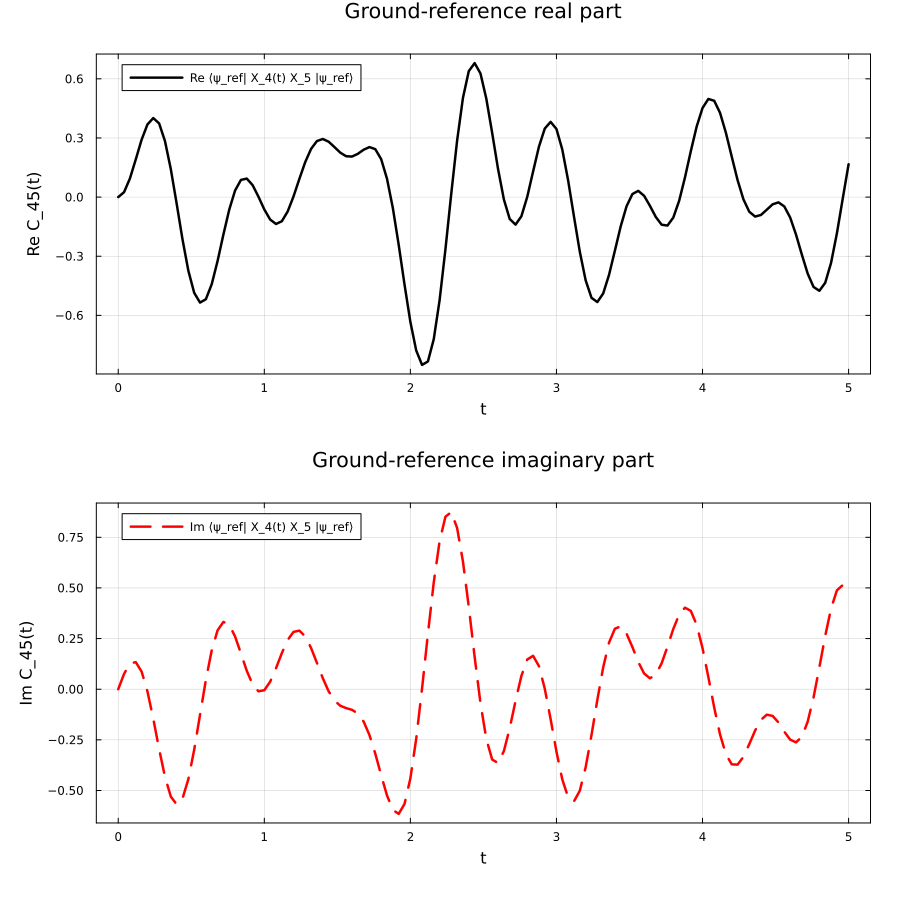

In [211]:
# Ground-reference two-point correlator setup
N = 8
J = -1.0 # Ferromagnetic: has product-state ground references |0> and |2^N-1>
H = heisenberg_xxx(N; J=J)

dt     = 0.04
T_max  = 5.0
times  = collect(0.0:dt:T_max)

E0, ψ_ref, ground_refs, ground_weights = dominant_ground_reference(H, dominance=0.10)
# ψ_ref = Ket{N}(0)
i = 4
j = 5
Xi = PauliSum(Pauli(N; X=[i]))
Xj = PauliSum(Pauli(N; X=[j]))

println("Ground-state energy E0 = $(round(E0; digits=8))")
println("Using single computational-basis ground reference ψ_ref = |$(ψ_ref.v)>")
println("Available product ground references: ", [Int(ref.v) for ref in ground_refs])
println("Computing C_$(i)$(j)(t) = <ψ_ref| X_$(i)(t) X_$(j) |ψ_ref>...")

ev_exact = exact_two_point_curve(H, Xi, Xj, ψ_ref, times)
drift = maximum(abs.(ev_exact .- ev_exact[1]))
println("C(0) = $(round(ev_exact[1]; digits=8)), max |C(t)-C(0)| = $(round(drift; digits=8))")
if drift < 1e-10
    println("Flat curve expected here: ψ_ref is an eigenstate of H and X_j acts diagonally on it.")
end

p_real = plot(times, real.(ev_exact),
    label="Re ⟨ψ_ref| X_$(i)(t) X_$(j) |ψ_ref⟩",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Re C_$(i)$(j)(t)",
    title="Ground-reference real part", legend=:topleft,
    size=(800, 400), framestyle=:box, margin=5Plots.mm, dpi=100)

p_imag = plot(times, imag.(ev_exact),
    label="Im ⟨ψ_ref| X_$(i)(t) X_$(j) |ψ_ref⟩",
    color=:red, lw=2.5, ls=:dash,
    xlabel="t", ylabel="Im C_$(i)$(j)(t)",
    title="Ground-reference imaginary part", legend=:topleft,
    size=(800, 400), framestyle=:box, margin=5Plots.mm, dpi=100)

plot(p_real, p_imag, layout=(2, 1), size=(900, 900))

In [89]:
# thresh = 1e-6
# @time ev_tr, nt_tr, W_mat_coeft = trotter_ev_curve(H, Xi, Xj, ψ_ref, times, dt, CoeffTruncation(thresh))

# p1 = plot(times, real.(ev_exact),
#           label="exact", color=:black, lw=2.5,
#           xlabel="t", ylabel="Re C_$(i)$(j)(t)",
#           title="Exact vs Pauli propagation", legend=:topleft,
#           framestyle=:box, margin=5Plots.mm, dpi=100)

# plot!(p1, times, ev_tr,
#           label="CoeffTruncation($(thresh))", color=:blue, ls=:dash, lw = 2)
    
# p1    

Computing Pauli-propagation curve with CoeffTruncation(0.001)...
  2.452370 seconds (127.83 k allocations: 1.812 GiB, 20.82% gc time)


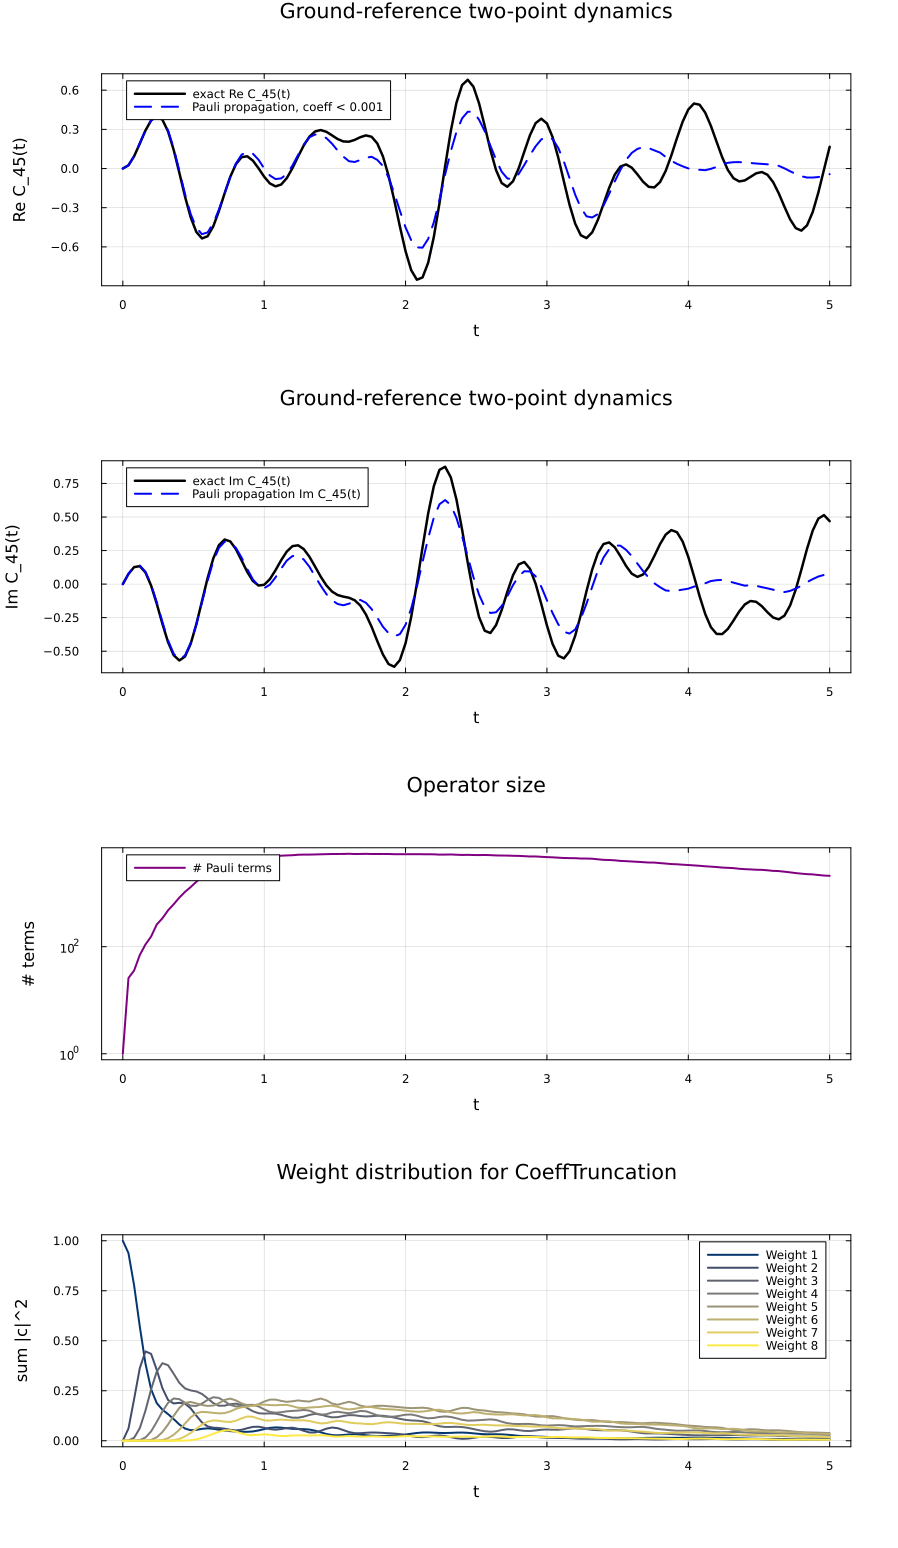

In [212]:
# Pauli-propagation / Trotter dynamics for the same ground-reference correlator
thresh = 1e-3
truncation = CoeffTruncation(thresh)

println("Computing Pauli-propagation curve with CoeffTruncation($(thresh))...")
@time ev_tr, nt_tr, W_mat_coeft = trotter_ev_curve(H, Xi, Xj, ψ_ref, times, dt, truncation)

# max_err = maximum(abs.(ev_tr .- (ev_exact)))
# println("max |C_trotter(t) - Re C_exact(t)| = $(round(max_err; digits=8))")

p_corr = plot(times, real.(ev_exact),
    label="exact Re C_$(i)$(j)(t)",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Re C_$(i)$(j)(t)",
    title="Ground-reference two-point dynamics", legend=:topleft,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)
plot!(p_corr, times, real.(ev_tr),
    label="Pauli propagation, coeff < $(thresh)",
    color=:blue, lw=2, ls=:dash)

p_corr_im = plot(times, imag.(ev_exact),
    label="exact Im C_$(i)$(j)(t)",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Im C_$(i)$(j)(t)",
    title="Ground-reference two-point dynamics", legend=:topleft,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)

plot!(p_corr_im, times, imag.(ev_tr),
    label="Pauli propagation Im C_$(i)$(j)(t)",
    color=:blue, lw=2, ls=:dash)
p_terms = plot(times, nt_tr,
    label="# Pauli terms", color=:purple, lw=2,
    xlabel="t", ylabel="# terms", yscale=:log10,
    title="Operator size", legend=:topleft,
    size=(850, 300), framestyle=:box, margin=5Plots.mm, dpi=100)


p_dist = plot(xlabel="t",
    ylabel="sum |c|^2",
    title="Weight distribution for CoeffTruncation",
    legend=:topright,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)

colors = cgrad(:cividis, N + 1, categorical=true)
for w in 0:N
    if maximum(W_mat_coeft[:, w + 1]) > 1e-12
        plot!(p_dist, times, W_mat_coeft[:, w + 1],
            label="Weight $w", linewidth=2, color=colors[w + 1])
    end
end

p_dist

plot(p_corr, p_corr_im, p_terms, p_dist, layout=(4, 1), size=(900, 1550), framestyle=:box, margin=1Plots.cm, dpi=100)

Computing Pauli-propagation curve with CoeffTruncation(0.001)...
  0.061554 seconds (68.33 k allocations: 90.132 MiB, 6.02% gc time)


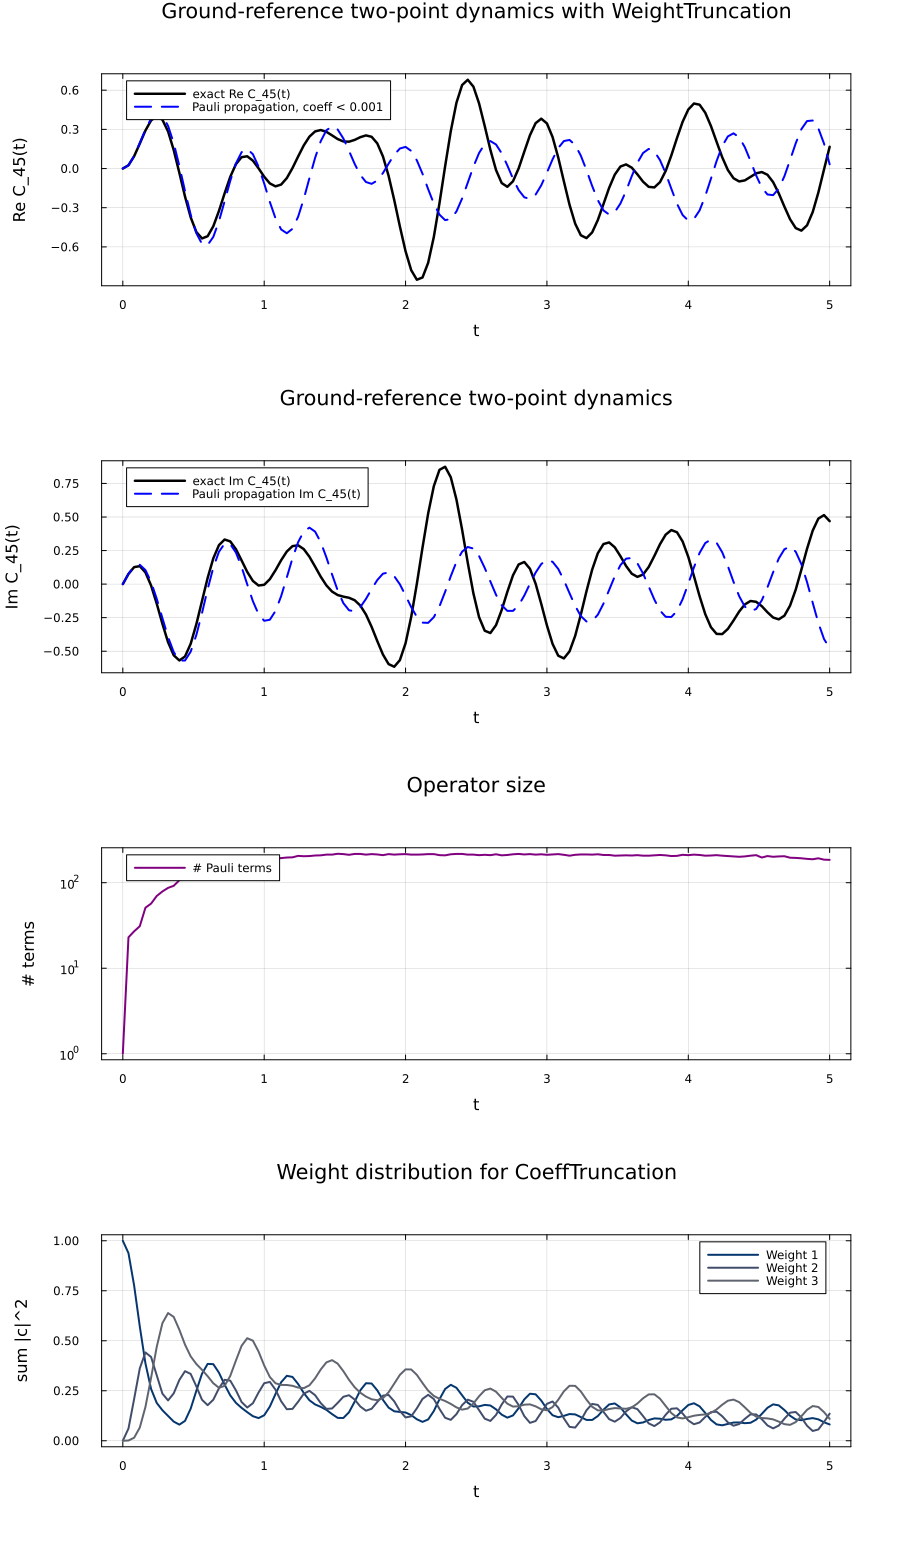

In [222]:
# Pauli-propagation / Trotter dynamics for the same ground-reference correlator
thresh = 1e-3
k_max = 3
truncation = CompositeTruncation(WeightTruncation(k_max), CoeffTruncation(thresh))
# truncation = WeightTruncation(k_max)
println("Computing Pauli-propagation curve with CoeffTruncation($(thresh))...")
@time ev_tr, nt_tr, W_mat_coeft = trotter_ev_curve(H, Xi, Xj, ψ_ref, times, dt, truncation)

# max_err = maximum(abs.(ev_tr .- (ev_exact)))
# println("max |C_trotter(t) - Re C_exact(t)| = $(round(max_err; digits=8))")

p_corr = plot(times, real.(ev_exact),
    label="exact Re C_$(i)$(j)(t)",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Re C_$(i)$(j)(t)",
    title="Ground-reference two-point dynamics with WeightTruncation", legend=:topleft,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)
plot!(p_corr, times, real.(ev_tr),
    label="Pauli propagation, coeff < $(thresh)",
    color=:blue, lw=2, ls=:dash)

p_corr_im = plot(times, imag.(ev_exact),
    label="exact Im C_$(i)$(j)(t)",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Im C_$(i)$(j)(t)",
    title="Ground-reference two-point dynamics", legend=:topleft,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)

plot!(p_corr_im, times, imag.(ev_tr),
    label="Pauli propagation Im C_$(i)$(j)(t)",
    color=:blue, lw=2, ls=:dash)
p_terms = plot(times, nt_tr,
    label="# Pauli terms", color=:purple, lw=2,
    xlabel="t", ylabel="# terms", yscale=:log10,
    title="Operator size", legend=:topleft,
    size=(850, 300), framestyle=:box, margin=5Plots.mm, dpi=100)


p_dist = plot(xlabel="t",
    ylabel="sum |c|^2",
    title="Weight distribution for CoeffTruncation",
    legend=:topright,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)

colors = cgrad(:cividis, N + 1, categorical=true)
for w in 0:N
    if maximum(W_mat_coeft[:, w + 1]) > 1e-12
        plot!(p_dist, times, W_mat_coeft[:, w + 1],
            label="Weight $w", linewidth=2, color=colors[w + 1])
    end
end

p_dist

plot(p_corr, p_corr_im, p_terms, p_dist, layout=(4, 1), size=(900, 1550), framestyle=:box, margin=1Plots.cm, dpi=100)

Computing Pauli-propagation curve with CoeffTruncation(0.001)...
  1.068317 seconds (25.22 M allocations: 2.377 GiB, 16.38% gc time)


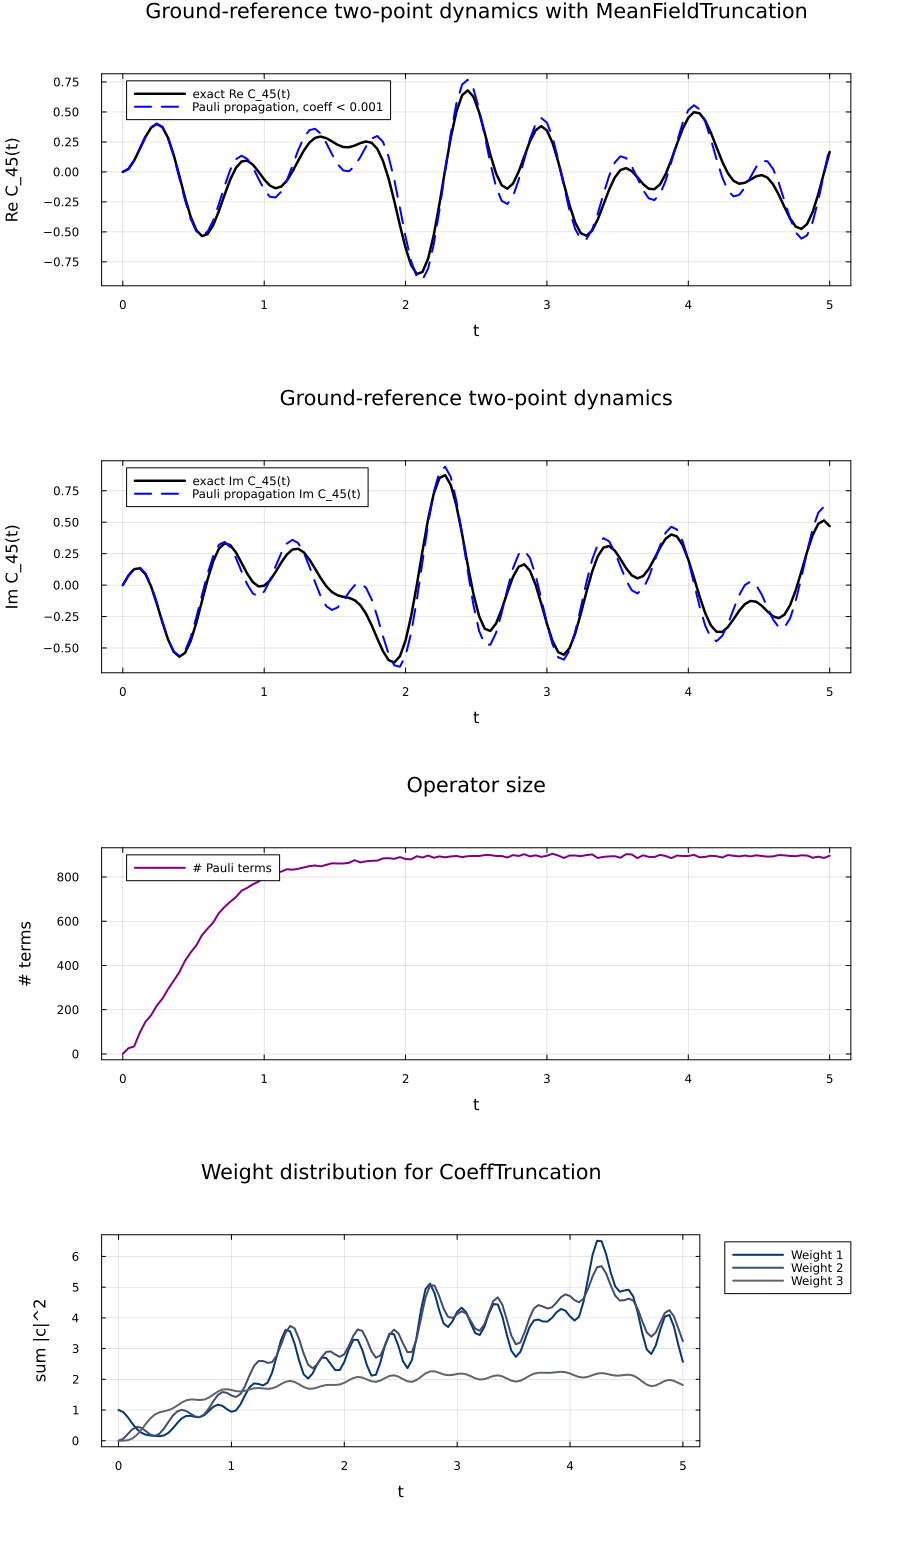

In [223]:
# Pauli-propagation / Trotter dynamics for the same ground-reference correlator
thresh = 1e-3
k_max = 3
truncation = CompositeTruncation(MeanFieldTruncation(k_max, ψ_ref), CoeffTruncation(thresh))
# truncation = MeanFieldTruncation(k_max, ψ_ref)
println("Computing Pauli-propagation curve with CoeffTruncation($(thresh))...")
@time ev_tr, nt_tr, W_mat_coeft = trotter_ev_curve(H, Xi, Xj, ψ_ref, times, dt, truncation)

# max_err = maximum(abs.(ev_tr .- (ev_exact)))
# println("max |C_trotter(t) - Re C_exact(t)| = $(round(max_err; digits=8))")

p_corr = plot(times, real.(ev_exact),
    label="exact Re C_$(i)$(j)(t)",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Re C_$(i)$(j)(t)",
    title="Ground-reference two-point dynamics with MeanFieldTruncation", legend=:topleft,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)
plot!(p_corr, times, real.(ev_tr),
    label="Pauli propagation, coeff < $(thresh)",
    color=:blue, lw=2, ls=:dash)

p_corr_im = plot(times, imag.(ev_exact),
    label="exact Im C_$(i)$(j)(t)",
    color=:black, lw=2.5, ls=:solid,
    xlabel="t", ylabel="Im C_$(i)$(j)(t)",
    title="Ground-reference two-point dynamics", legend=:topleft,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)

plot!(p_corr_im, times, imag.(ev_tr),
    label="Pauli propagation Im C_$(i)$(j)(t)",
    color=:blue, lw=2, ls=:dash)
p_terms = plot(times, nt_tr,
    label="# Pauli terms", color=:purple, lw=2,
    xlabel="t", ylabel="# terms", #yscale=:log10,
    title="Operator size", legend=:topleft,
    size=(850, 300), framestyle=:box, margin=5Plots.mm, dpi=100)


p_dist = plot(xlabel="t",
    ylabel="sum |c|^2",
    title="Weight distribution for CoeffTruncation",
    legend=:outertopright,
    size=(850, 450), framestyle=:box, margin=5Plots.mm, dpi=100)

colors = cgrad(:cividis, N + 1, categorical=true)
for w in 0:N
    if maximum(W_mat_coeft[:, w + 1]) > 1e-12
        plot!(p_dist, times, W_mat_coeft[:, w + 1],
            label="Weight $w", linewidth=2, color=colors[w + 1])
    end
end

p_dist

plot(p_corr, p_corr_im, p_terms, p_dist, layout=(4, 1), size=(900, 1550), framestyle=:box, margin=1Plots.cm, dpi=100)
# savefig("ground_reference_correlator_dynamics.png")


In [228]:
M = rand(PauliSum{3}; n_paulis=5)
ψ = Ket{3}(0)
display(M)
println("===============================")
kmax = 2
truncation = MeanFieldTruncation(kmax, ψ)
Q = deepcopy(M)
truncate!(Q, truncation)
Q

   0.08628536 +  0.58103662i YIZ
   1.01234009 + -0.35419468i IXX
  -0.70465917 + -0.31626222i YYX
   0.03212676 + -0.08971418i ZYZ


   0.08628536 +  0.58103662i YIZ
   0.03212676 + -0.08971418i IYZ
   1.01234009 + -0.35419468i IXX
  -0.03212676 +  0.08971418i IYI
   0.03212676 + -0.08971418i ZYI


In [229]:
kmax = 1
truncation = MeanFieldTruncation(kmax, ψ)
Q = deepcopy(M)
truncate!(Q, truncation)
Q

   0.03212676 + -0.08971418i IYI
   0.08628536 +  0.58103662i YII
